# **Solving the CVRP using Multimodal PSO**
In this notebook, we will explore and evaluate different multimodal Particle Swarm Optimization (PSO) algorithms to solve the Capacitated Vehicle Routing Problem (CVRP).

## **Why use PSO?**
The CVRP is naturally a discrete and combinatorial problem. However, we can leverage PSO (an algorithm originally designed for continuous spaces) by using the **Smallest Position Value (SPV)** rule. This decoding technique allows us to transform continuous particle coordinates (vectors bounded between 0.0 and 1.0) into ordered discrete sequences, effectively mapping a continuous trajectory into a valid sequence of customers.

## **Which algorithms are we going to evaluate?**
We have implemented 4 baseline multimodal techniques and 1 advanced hybrid approach. All of them are based on the core PSO engine, but each introduces a unique mechanism to maintain diversity and find multiple niches.

In [1]:
# Librerias a usar
from typing import Optional  # Clase para el tipado
from src.common.parser import Parser  # Clase que traduce el fichero a problema
from src.common.problem import CVRPProblem  # Clase que carga el problema
from src.pso.pso_algorithm import PSOAlgorithm  # Clase PSO que ejecutara el algoritmo (por dentro con inspyred)
from src.common.visualizer import VisualizadorCVRP  # Clase para visualizar metricas
from src.pso.base_pso import BasePSO  # Clase que define la configuracion del PSO

In [2]:
# Funcion que automatiza la ejecucion y pintado recibiendo objetos tipados
def ejecutar_y_visualizar(
        tecnica_pso: BasePSO, 
        motor_pso: PSOAlgorithm, 
        datos_problema: CVRPProblem,
        num_iteraciones: Optional[int]=None
    ) -> None:

    # Reseteamos el motor
    motor_pso.clear()

    # Comprobamos si tenemos numero de iteraciones
    if num_iteraciones:

        # Ejecutamos el algoritmo (Secuencial)
        motor_pso.ejecutar(tecnica_pso, num_iteraciones)
    
    # Si no, ejecutamos los online
    else:
        motor_pso.ejecutar(tecnica_pso)
    
    # Instanciamos la clase encargada de pintar los resultados
    visualizador = VisualizadorCVRP(datos_problema)
    
    # Dibujamos la evolucion del metodo
    visualizador.dibujar_evolucion(
        motor_pso.historico_fitness_mejor, 
        motor_pso.historico_fitness_media, 
        motor_pso.historico_diversidad
    )
    
    # Visualizamos el histograma y el boxplot
    for i, solucion in enumerate(motor_pso.mejores_soluciones):
        
        # Pasamos el vector [0.5, 0.1...] a ruta discreta [1, 4, 2...]
        ruta_sucia = tecnica_pso._decodificar_spv(solucion.candidate)
        ruta_limpia = tecnica_pso._aplicar_2_opt_ruta(ruta_sucia)
        
        # Dibujamos el mapa
        visualizador.dibujar_distribucion_poblacion(ruta_limpia)

In [3]:
# Ruta del dataset
ruta_dataset: str = '../data/X-n1001-k43.vrp'

# Extraemos el numero de camiones maximo
maximo_camiones: int = int(ruta_dataset.split('-k')[1].split('.')[0])

# Cargamos los datos
parser: Parser = Parser(ruta_dataset)
nodos, demandas, capacidad = parser.parse()

# Instanciamos el CVRP con los datos leídos
datos_cvrp: CVRPProblem = CVRPProblem(nodos, demandas, capacidad)

Parser sucessfully loaded. 1001 nodes. Vehicle capacity: 131
[Problem] Distance matrix (1001x1001) precalculated.


### **The Sequential Method**
This approach involves running the PSO algorithm multiple consecutive times. At the end of each complete execution, the best solution found is stored. In subsequent runs, a radioactive penalty zone is placed around these historical optima. If a particle enters this radius, its fitness is heavily penalized, forcing the swarm to explore entirely new areas of the map. Let's see how it works:

In [4]:
# Librerias a usar
from src.pso.sequential_pso_algorithm import SequentialPSOAlgorithm
from src.pso.multimodal_techniques.sequential_pso import SequentialPSO

In [5]:
# Definimos el motor secuencial
motor_secuencial: SequentialPSOAlgorithm = SequentialPSOAlgorithm(
    tamano_poblacion=100,
    max_evaluaciones=1000,
    inercia=0.7,
    cognitivo=1.5,
    social=1.5,
    tamano_vecindario=25
)

# Definimos la clase para la configuracion secuencial
config_secuencial: SequentialPSO = SequentialPSO(datos_cvrp)

# Ejecutamos
# ejecutar_y_visualizar(config_secuencial, motor_secuencial, datos_cvrp, 3)

### **The Fitness Sharing Method**
This technique maintains diversity by penalizing particles that cluster too closely together within the same generation. It calculates the spatial density of the swarm using a predefined "niche radius." If a specific region of the map becomes too crowded, the fitness of the particles inside it is artificially degraded (shared among the neighbors). This mechanism prevents the entire swarm from converging prematurely on a single local optimum, actively encouraging particles to spread out and explore less populated areas of the solution space.

In [6]:
# Librerias a usar
from src.pso.pso_algorithm import PSOAlgorithm
from src.pso.multimodal_techniques.fitness_sharing_pso import FitnessSharingPSO

In [7]:
# Definimos el motor multimodal (se reusara para los demas)
motor_multimodal: PSOAlgorithm = PSOAlgorithm(
    tamano_poblacion=50,
    max_evaluaciones=100000,
    inercia=0.7,
    cognitivo=1.5,
    social=1.5,
    tamano_vecindario=10
)

# Definimos la clase para la configuracion secuencial
config_sharing: FitnessSharingPSO = FitnessSharingPSO(
    datos_problema=datos_cvrp,
    radio=0.05,
    alpha=1.0,
    num_soluciones_corregir=15,
)

# Ejecutamos
# ejecutar_y_visualizar(config_sharing, motor_multimodal, datos_cvrp)

### **The Clearing Method**
Closely related to Fitness Sharing, the Clearing method also operates within a specific spatial radius but takes a much more aggressive, "winner-takes-all" approach. In every generation, particles are evaluated and sorted by their performance. The best particle in a given region is crowned as the "niche champion" and retains its true fitness. However, any subordinate particles that fall within the champion's radius are heavily penalized (effectively "cleared"). This strategy perfectly preserves the elite solutions while forcing the rest of the swarm to continuously search for new, undiscovered niches.

### **The Species Competition Method**
Unlike penalty-based approaches, the Species Competition method (or Species-based PSO) promotes diversity by intelligently dividing the main swarm into multiple, self-contained sub-populations called "species." At each generation, particles are grouped based on their spatial proximity (defined by a species radius) around a dominant particle, known as the "species seed." Each species then evolves independently, optimizing its own local niche without being overwhelmingly pulled by a single global leader. This parallel, cooperative-competitive behavior allows the algorithm to simultaneously locate and maintain multiple optimal solutions (distinct vehicle routes) across the search space without destroying secondary niches.

### **Improving PSO using Clústering algorithms**
Complete

In [8]:
# Libreria a usar
from src.common.clustering.clustering_manager import ClusteringManager  # Clase que nos dividira el problema gigante en sub-problemas

In [9]:
# Calculamos el K ideal para no saturar al PSO
total_clientes: int = len(nodos) - 1
k_ideal: int = ClusteringManager.calcular_k_ideal(total_clientes, max_clientes_por_cluster=40)

# Generamos la lista con los sub-problemas (objetos de tipo ClusterCVRPProblem)
sub_problemas: list = ClusteringManager.generar_sub_problemas(nodos, demandas, capacidad, k_ideal)

# Imprimimos el resultado de la division
print(f'Mapa dividido exitosamente en {len(sub_problemas)} clústers de trabajo.')

[Problem] Distance matrix (35x35) precalculated.
[Problem] Distance matrix (64x64) precalculated.
[Problem] Distance matrix (37x37) precalculated.
[Problem] Distance matrix (32x32) precalculated.
[Problem] Distance matrix (41x41) precalculated.
[Problem] Distance matrix (41x41) precalculated.
[Problem] Distance matrix (46x46) precalculated.
[Problem] Distance matrix (35x35) precalculated.
[Problem] Distance matrix (38x38) precalculated.
[Problem] Distance matrix (57x57) precalculated.
[Problem] Distance matrix (23x23) precalculated.
[Problem] Distance matrix (29x29) precalculated.
[Problem] Distance matrix (49x49) precalculated.
[Problem] Distance matrix (45x45) precalculated.
[Problem] Distance matrix (42x42) precalculated.
[Problem] Distance matrix (50x50) precalculated.
[Problem] Distance matrix (48x48) precalculated.
[Problem] Distance matrix (41x41) precalculated.
[Problem] Distance matrix (31x31) precalculated.
[Problem] Distance matrix (54x54) precalculated.
[Problem] Distance m

In [10]:
"""
# Definimos el motor (reusable para todos los clústers)
motor_pso: PSOAlgorithm = PSOAlgorithm(
    tamano_poblacion=40,
    max_evaluaciones=20000,  # Reducido porque cada zona es mucho mas pequeña
    inercia=0.7,
    cognitivo=1.5,
    social=1.5,
    tamano_vecindario=5
)

# Variables globales para guardar el ensamblaje final
ruta_global_ensamblada: list = []
distancia_total_real: float = 0.0

# Iteramos por cada zona creada por el ClusteringManager
for i, problema_local in enumerate(sub_problemas):
    
    print(f'--- Resolviendo Zona {i + 1}/{len(sub_problemas)} ---')
    
    # IMPORTANTE: Reseteamos el motor para no mezclar particulas de la zona anterior
    motor_pso.clear()
    
    # Definimos la tecnica multimodal pasandole EXCLUSIVAMENTE este sub-problema
    tecnica_local: FitnessSharingPSO = FitnessSharingPSO(
        datos_problema=problema_local,
        radio=0.05,
        alpha=1.0,
        num_soluciones_corregir=5
    )
    
    # Ejecutamos el PSO online para esta zona
    motor_pso.ejecutar(tecnica_local)
    
    # Extraemos la mejor solucion local
    mejor_particula = motor_pso.mejores_soluciones[0]
    
    # Pasamos el vector [0.5, 0.1...] a ruta discreta y le aplicamos el 2-opt
    ruta_sucia: list = tecnica_local._decodificar_spv(mejor_particula.candidate)
    ruta_limpia: list = tecnica_local._aplicar_2_opt_ruta(ruta_sucia)
    
    # Usamos el problema global para saber los km reales sin el castigo
    distancia_tramo: float = datos_cvrp.evaluate_route_distance(ruta_limpia)
    distancia_total_real += distancia_tramo
    
    # Ensamblamos al tour gigante (ignoramos el primer deposito para no duplicarlo al empalmar)
    if not ruta_global_ensamblada:
        ruta_global_ensamblada.extend(ruta_limpia)
    else:
        ruta_global_ensamblada.extend(ruta_limpia[1:])

# Reporte final
print('=' * 50)
print(f'EJECUCIÓN COMPLETADA - Distancia Total: {distancia_total_real:.2f}')

# Instanciamos el visualizador pasandole los datos del CVRP global para que pinte todo el mapa
visualizador: VisualizadorCVRP = VisualizadorCVRP(datos_cvrp)

# Dibujamos el mapa final completo
visualizador.dibujar_rutas(
    ruta_global_ensamblada, 
    titulo=f"Rutas Ensambladas tras Clustering (Distancia: {distancia_total_real:.2f})"
)


"""

'\n# Definimos el motor (reusable para todos los clústers)\nmotor_pso: PSOAlgorithm = PSOAlgorithm(\n    tamano_poblacion=40,\n    max_evaluaciones=20000,  # Reducido porque cada zona es mucho mas pequeña\n    inercia=0.7,\n    cognitivo=1.5,\n    social=1.5,\n    tamano_vecindario=5\n)\n\n# Variables globales para guardar el ensamblaje final\nruta_global_ensamblada: list = []\ndistancia_total_real: float = 0.0\n\n# Iteramos por cada zona creada por el ClusteringManager\nfor i, problema_local in enumerate(sub_problemas):\n\n    print(f\'--- Resolviendo Zona {i + 1}/{len(sub_problemas)} ---\')\n\n    # IMPORTANTE: Reseteamos el motor para no mezclar particulas de la zona anterior\n    motor_pso.clear()\n\n    # Definimos la tecnica multimodal pasandole EXCLUSIVAMENTE este sub-problema\n    tecnica_local: FitnessSharingPSO = FitnessSharingPSO(\n        datos_problema=problema_local,\n        radio=0.05,\n        alpha=1.0,\n        num_soluciones_corregir=5\n    )\n\n    # Ejecutamos el 

Rellenar

In [11]:
# Importas la nueva clase
from src.common.clustering.angular_clustering_manager import AngularClusteringManager

In [12]:
# Generas los problemas (internamente usará el KMeans polar y el agrupamiento del padre)
sub_problemas: list = AngularClusteringManager.generar_sub_problemas(nodos, demandas, capacidad, k_ideal, truck_penalty=4)

# Imprimimos el resultado de la division
print(f'Mapa dividido exitosamente en {len(sub_problemas)} clústers de trabajo.')

[Problem] Distance matrix (53x53) precalculated.
[Problem] Distance matrix (45x45) precalculated.
[Problem] Distance matrix (36x36) precalculated.
[Problem] Distance matrix (42x42) precalculated.
[Problem] Distance matrix (59x59) precalculated.
[Problem] Distance matrix (46x46) precalculated.
[Problem] Distance matrix (69x69) precalculated.
[Problem] Distance matrix (28x28) precalculated.
[Problem] Distance matrix (32x32) precalculated.
[Problem] Distance matrix (50x50) precalculated.
[Problem] Distance matrix (13x13) precalculated.
[Problem] Distance matrix (25x25) precalculated.
[Problem] Distance matrix (42x42) precalculated.
[Problem] Distance matrix (45x45) precalculated.
[Problem] Distance matrix (31x31) precalculated.
[Problem] Distance matrix (44x44) precalculated.
[Problem] Distance matrix (44x44) precalculated.
[Problem] Distance matrix (56x56) precalculated.
[Problem] Distance matrix (38x38) precalculated.
[Problem] Distance matrix (51x51) precalculated.
[Problem] Distance m

In [13]:
import time

from src.common.clustering.join_routes import JoinRoutes
from src.common.clustering.parallel import ParallelClustering

Parser sucessfully loaded. 1001 nodes. Vehicle capacity: 131
[Problem] Distance matrix (1001x1001) precalculated.
Instancia cargada: ../data/X-n1001-k43.vrp
Límite de camiones: 43
[Problem] Distance matrix (53x53) precalculated.
[Problem] Distance matrix (45x45) precalculated.
[Problem] Distance matrix (36x36) precalculated.
[Problem] Distance matrix (42x42) precalculated.
[Problem] Distance matrix (59x59) precalculated.
[Problem] Distance matrix (46x46) precalculated.
[Problem] Distance matrix (69x69) precalculated.
[Problem] Distance matrix (28x28) precalculated.
[Problem] Distance matrix (32x32) precalculated.
[Problem] Distance matrix (50x50) precalculated.
[Problem] Distance matrix (13x13) precalculated.
[Problem] Distance matrix (25x25) precalculated.
[Problem] Distance matrix (42x42) precalculated.
[Problem] Distance matrix (45x45) precalculated.
[Problem] Distance matrix (31x31) precalculated.
[Problem] Distance matrix (44x44) precalculated.
[Problem] Distance matrix (44x44) pr

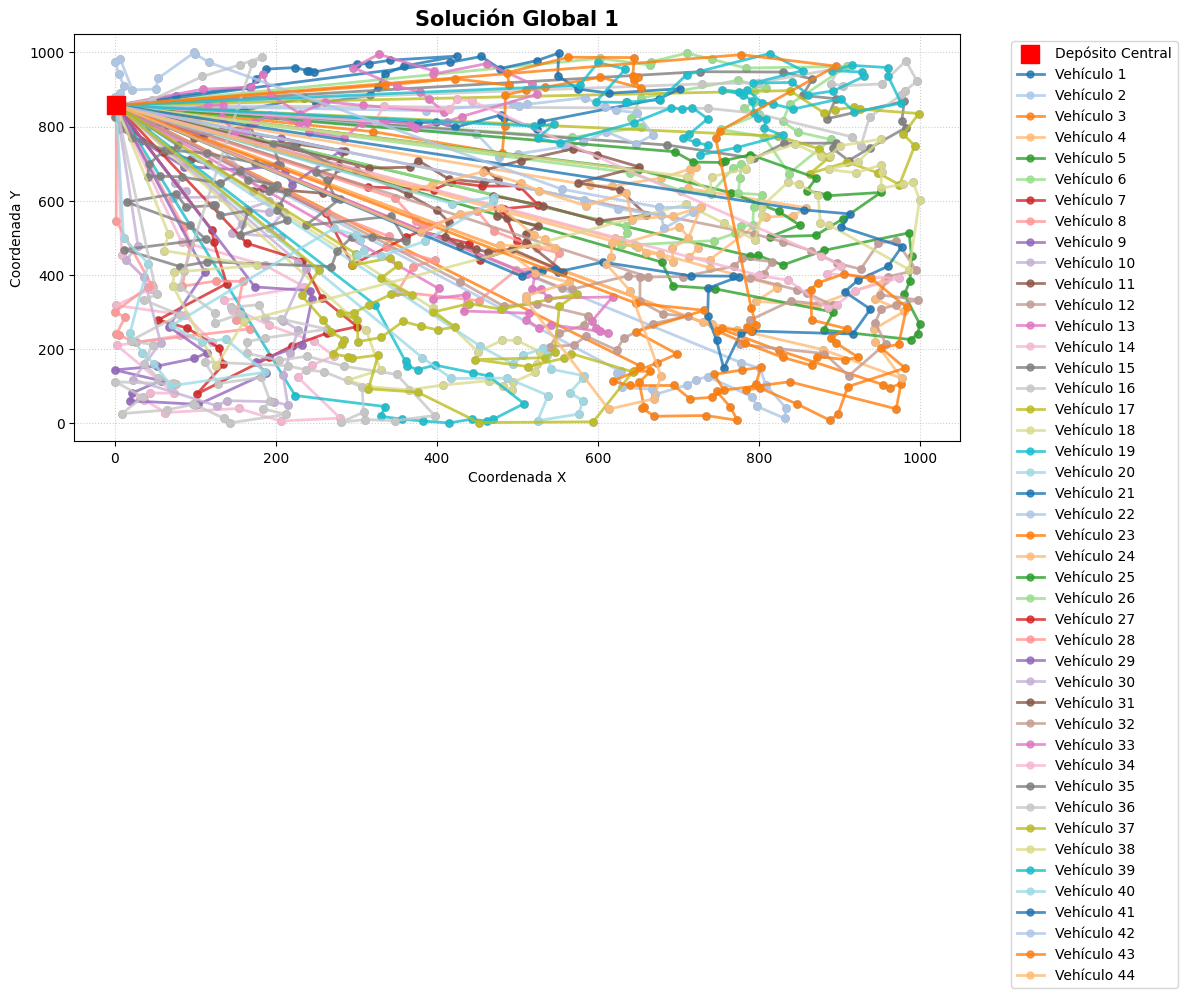

Rutas fusionadas. Camiones actuales: 54
Rutas fusionadas. Camiones actuales: 53
Rutas fusionadas. Camiones actuales: 52
Rutas fusionadas. Camiones actuales: 51
Rutas fusionadas. Camiones actuales: 50
Rutas fusionadas. Camiones actuales: 49
Rutas fusionadas. Camiones actuales: 48
Rutas fusionadas. Camiones actuales: 47
Rutas fusionadas. Camiones actuales: 46
Rutas fusionadas. Camiones actuales: 45
Rutas fusionadas. Camiones actuales: 44
Limite fisico de capacidad alcanzado. Imposible reducir a 43.
Mapa 2 | Distancia: 99540.49 | Camiones: 44


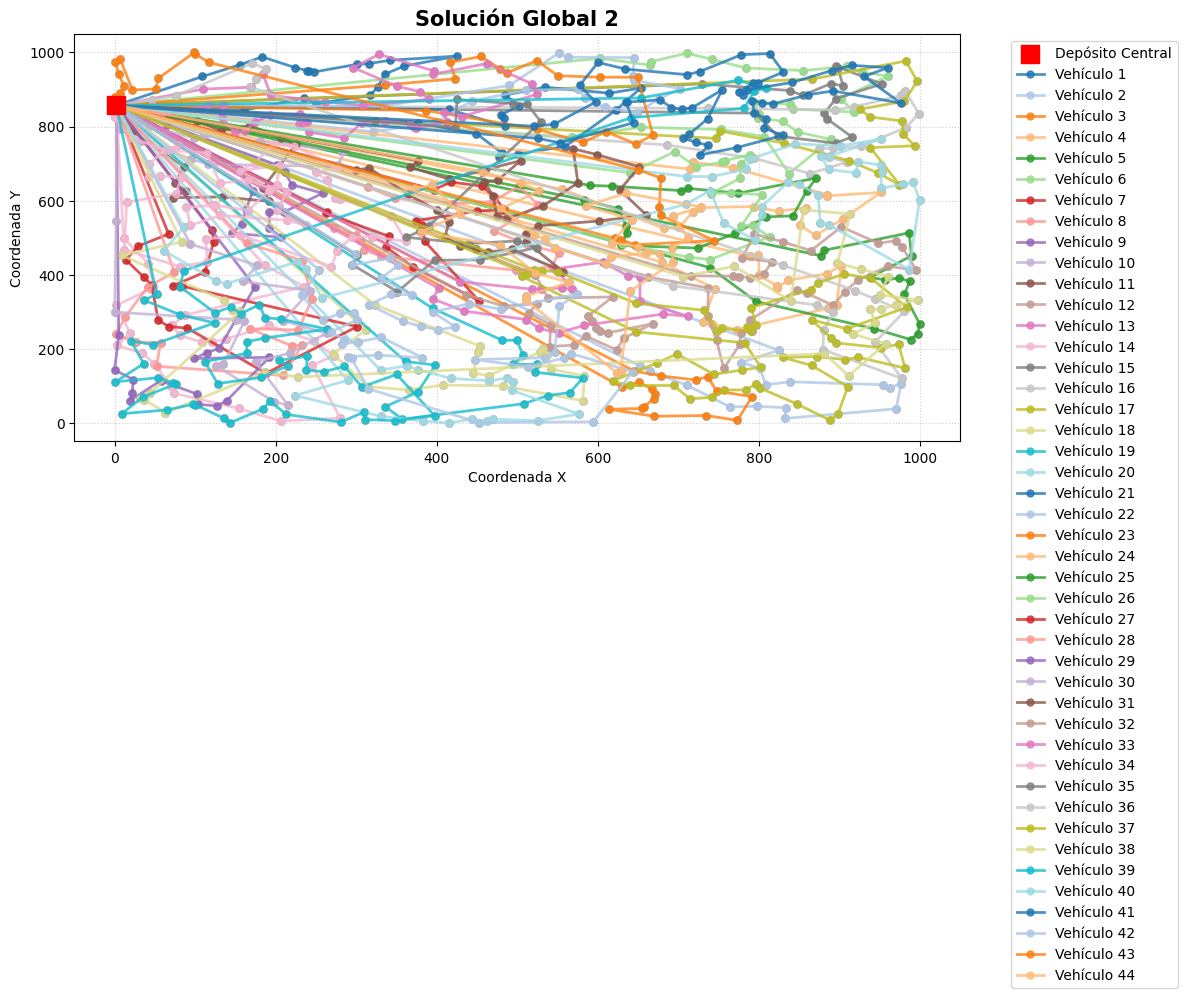

Rutas fusionadas. Camiones actuales: 54
Rutas fusionadas. Camiones actuales: 53
Rutas fusionadas. Camiones actuales: 52
Rutas fusionadas. Camiones actuales: 51
Rutas fusionadas. Camiones actuales: 50
Rutas fusionadas. Camiones actuales: 49
Rutas fusionadas. Camiones actuales: 48
Rutas fusionadas. Camiones actuales: 47
Rutas fusionadas. Camiones actuales: 46
Rutas fusionadas. Camiones actuales: 45
Rutas fusionadas. Camiones actuales: 44
Limite fisico de capacidad alcanzado. Imposible reducir a 43.
Mapa 3 | Distancia: 99746.40 | Camiones: 44


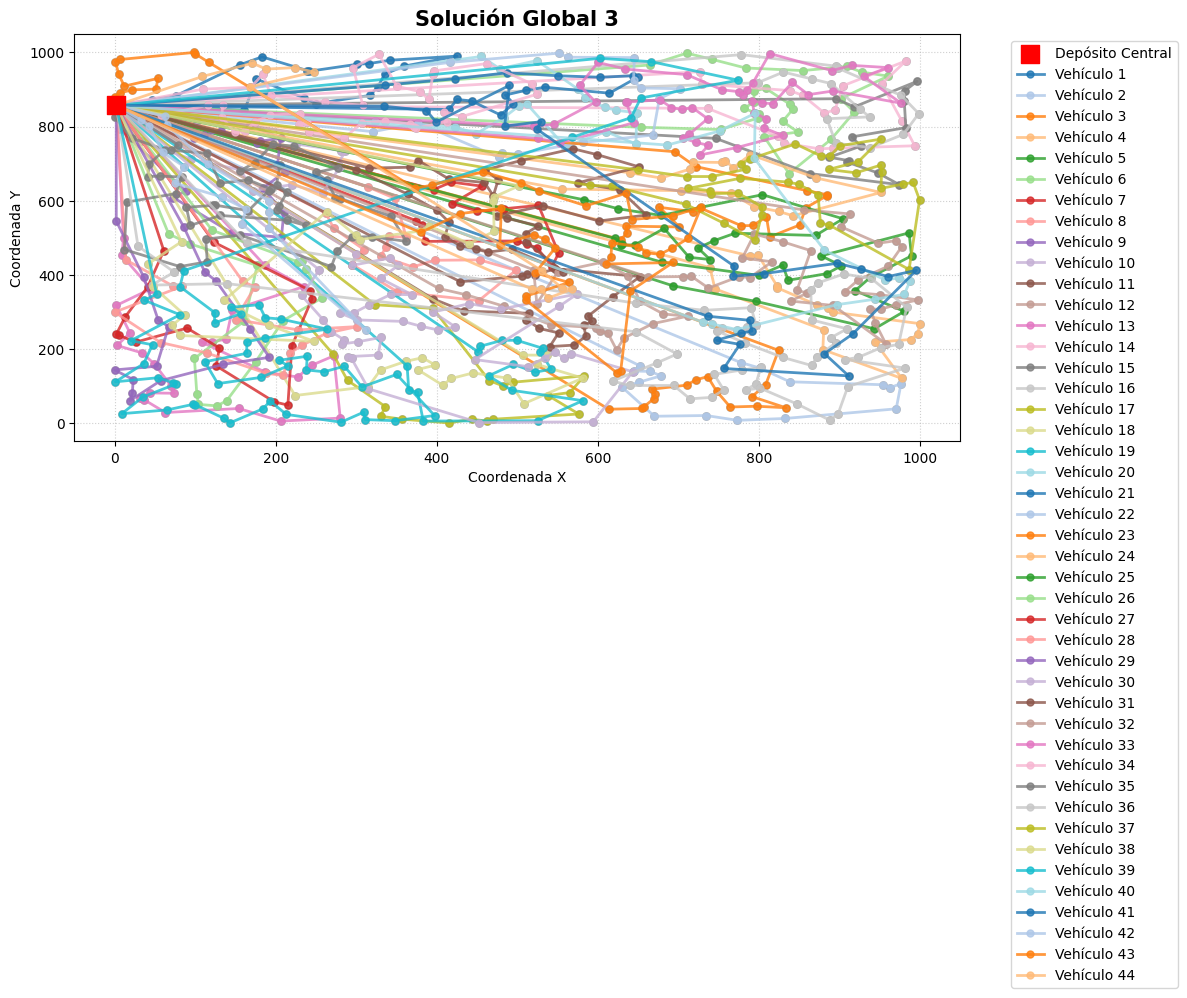


DIVERSIDAD JACCARD ENTRE MAPAS GLOBALES


NameError: name 'DiversityHandler' is not defined

In [ ]:
# 1. PARÁMETROS DE LA INSTANCIA (1001 NODOS)
ruta_archivo: str = '../data/X-n1001-k43.vrp'
limite_vehiculos_real: int = int(ruta_archivo.split('-k')[1].split('.')[0])

# Carga de datos
parser: Parser = Parser(ruta_archivo)
nodos, demandas, capacidad = parser.parse()
datos_cvrp: CVRPProblem = CVRPProblem(nodos, demandas, capacidad)
depot_id: int = list(nodos.keys())[0]

print(f"Instancia cargada: {ruta_archivo}")
print(f"Límite de camiones: {limite_vehiculos_real}")

# 2. CLUSTERING (40 clientes por zona = ~25 zonas para 1001 nodos)
total_clientes: int = len(nodos) - 1
k_ideal: int = ClusteringManager.calcular_k_ideal(total_clientes, max_clientes_por_cluster=40)

sub_problemas: list = AngularClusteringManager.generar_sub_problemas(
    nodos, demandas, capacidad, k_ideal, truck_penalty=4
)
print(f'Mapa dividido en {len(sub_problemas)} zonas.')

# ---------------------------------------------------------
# 3. CONFIGURACIÓN DE LOS DOS DICCIONARIOS (Tu estilo)
# ---------------------------------------------------------

# Diccionario de motor
parametros_pso: dict = {
    'tamano_poblacion': 40,
    'max_evaluaciones': 6000,
    'inercia': 0.7, 
    'cognitivo': 1.5, 
    'social': 1.5
}

# TUS PARÁMETROS ORIGINALES (Los que te daban 0.65)
parametros_config_pso: dict = {
    'umbral_similitud': 0.75, 
    'penalizacion': 1e12,
    'num_soluciones_corregir': 3 
}

num_ejecuciones_globales: int = 3
visualizador: VisualizadorCVRP = VisualizadorCVRP(datos_cvrp)

print('='*60)
print('CALCULANDO TODAS LAS ITERACIONES EN PARALELO...')
inicio_pso = time.time()

# EL MILAGRO: Una sola llamada resuelve las 3 vueltas de golpe
camiones_por_iteracion = ParallelClustering.resolver_todo_en_paralelo(
    sub_problemas=sub_problemas,
    parametros_pso=parametros_pso,
    parametros_config_pso=parametros_config_pso,
    depot_id=depot_id,
    num_ejecuciones=num_ejecuciones_globales
)
fin_pso = time.time()
print(f"Fase Paralela Total terminada en {fin_pso - inicio_pso:.2f} s.\n")

# ENSAMBLAJE Y DIVERSIDAD
historial_rutas_globales = [] 

for it in range(num_ejecuciones_globales):
    rutas_optimizadas_finales = JoinRoutes.consolidar_rutas(
        rutas_pso=camiones_por_iteracion[it], # Pillamos la bolsa de esta iteración
        demands=demandas, capacity=capacidad,
        limite_camiones=limite_vehiculos_real, depot_id=depot_id, nodes=nodos
    )
    
    ruta_global_ensamblada = []
    for ruta in rutas_optimizadas_finales:
        ruta_global_ensamblada.extend(ruta if not ruta_global_ensamblada else ruta[1:])
            
    distancia_final = datos_cvrp.evaluate_route_distance(ruta_global_ensamblada)
    print(f'Mapa {it + 1} | Distancia: {distancia_final:.2f} | Camiones: {len(rutas_optimizadas_finales)}')
    
    historial_rutas_globales.append(ruta_global_ensamblada)
    visualizador.dibujar_rutas(ruta_global_ensamblada, titulo=f"Solución Global {it + 1}")

In [15]:
# Importa tu clase si no lo has hecho arriba
from src.common.diversity import DiversityHandler

In [16]:
# 6. DIVERSIDAD FINAL
print('\n' + '='*60)
print('DIVERSIDAD JACCARD ENTRE MAPAS GLOBALES')
for i in range(len(historial_rutas_globales)):
    for j in range(i + 1, len(historial_rutas_globales)):
        score = DiversityHandler.calculate_jaccard_distance(historial_rutas_globales[i], historial_rutas_globales[j])
        print(f"Mapa {i+1} vs Mapa {j+1}: {score:.4f}")


DIVERSIDAD JACCARD ENTRE MAPAS GLOBALES
Mapa 1 vs Mapa 2: 0.6751
Mapa 1 vs Mapa 3: 0.6734
Mapa 2 vs Mapa 3: 0.6450
